# ТМО РК1 Панасюк Ксения ИУ5-64Б
Вариант: 18 (Задача 3, Датасет 2)

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.preprocessing import MinMaxScaler, LabelEncoder, OneHotEncoder

In [3]:
wine = load_wine()
df = pd.DataFrame(data=wine.data, columns=wine.feature_names)
# Добавляем целевую переменную как основу для категорий
df['target'] = wine.target

In [4]:
# Создадим признак "Alcohol_Intensity" на основе содержания алкоголя.
def define_intensity(alcohol):
    if alcohol < 12.5: return 'Low'
    elif alcohol < 13.5: return 'Medium'
    else: return 'High'

df['intensity'] = df['alcohol'].apply(define_intensity)

print("Первые 5 строк модифицированного датасета:")
display(df[['alcohol', 'intensity', 'magnesium']].head())

Первые 5 строк модифицированного датасета:


,alcohol,intensity,magnesium
0,14.23,High,127.0
1,13.20,Medium,100.0
2,13.16,Medium,101.0
3,14.37,High,113.0
4,13.24,Medium,118.0


In [7]:
# А) Масштабирование данных 
scaler = MinMaxScaler()
df['magnesium_scaled'] = scaler.fit_transform(df[['magnesium']])

# Б) Преобразование категориальных признаков в количественные (Label Encoding)
le = LabelEncoder()
df['intensity_label'] = le.fit_transform(df['intensity'])

# В) Преобразование категориальных признаков в количественные (One-Hot Encoding)
ohe = pd.get_dummies(df['intensity'], prefix='intensity_ohe')
df = pd.concat([df, ohe], axis=1)

print("\nРезультаты преобразований (фрагмент):")
display(df[['magnesium', 'magnesium_scaled', 'intensity', 'intensity_label', 'intensity_ohe_High']].head())



Результаты преобразований (фрагмент):


,magnesium,magnesium_scaled,intensity,intensity_label,intensity_ohe_High,intensity_ohe_High
0,127.0,0.619565,High,0,True,True
1,100.0,0.326087,Medium,2,False,False
2,101.0,0.336957,Medium,2,False,False
3,113.0,0.467391,High,0,True,True
4,118.0,0.521739,Medium,2,False,False


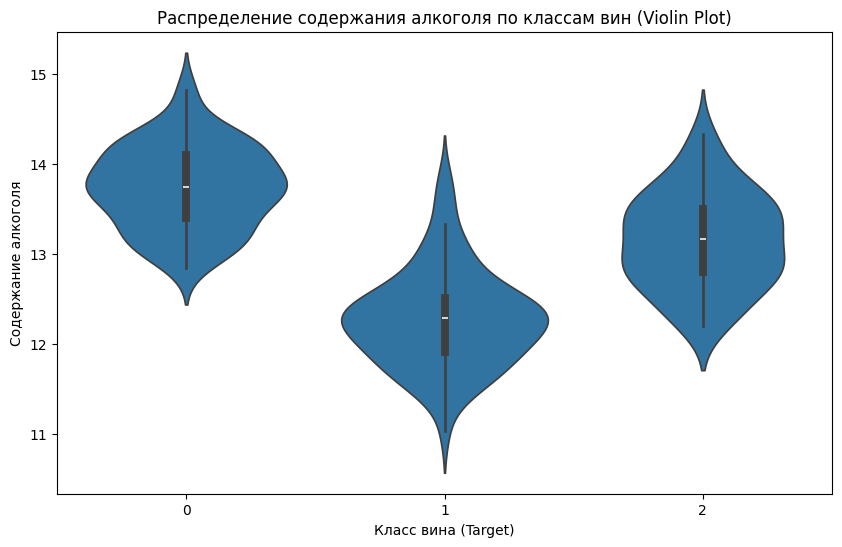

In [8]:
plt.figure(figsize=(10, 6))
sns.violinplot(x='target', y='alcohol', data=df)
plt.title('Распределение содержания алкоголя по классам вин (Violin Plot)')
plt.xlabel('Класс вина (Target)')
plt.ylabel('Содержание алкоголя')
plt.show()

# Использованные методы

Для нормализации признака magnesium был применен **метод MinMaxScaler**, который перевел исходные значения в диапазон [0,1]. Это необходимо для того, чтобы алгоритмы машинного обучения не придавали избыточный вес признакам с большими числовыми значениями, обеспечивая равный вклад всех параметров в итоговую модель.

**Метод Label Encoding** использовался для преобразования текстовых категорий интенсивности в целочисленные метки. Данный подход выбран из-за наличия логического порядка в данных, что позволяет сохранить информацию о соподчиненности значений без увеличения количества столбцов в таблице.

Для исключения ложной математической зависимости между категориями было выполнено **One-Hot кодирование**. Путем создания бинарных столбцов для каждой категории мы обеспечили корректную интерпретацию данных линейными моделями, для которых прямое использование чисел (0, 1, 2) могло бы ошибочно указывать на количественное превосходство одной категории над другой.

Была построена **скрипичная диаграмма** распределения алкоголя. Выбор этого графика обусловлен его способностью одновременно отображать ключевые статистические показатели (медиану, квартили) и плотность распределения данных, что позволяет визуально оценить компактность и симметричность признаков для каждого класса вин.